In [1]:
# Setup for Google Colab (optional)
import sys
if 'google.colab' in sys.modules:
    print("Running in Google Colab")
    # Install required packages
    !pip install -q py4DSTEM hyperspy scikit-image matplotlib numpy scipy
    
    # Clone the repository to access data
    !git clone -q https://github.com/NU-MSE-LECTURES/465-WINTER2026.git
    import os
    os.chdir('/content/465-WINTER2026')
    
    # Set up file handling
    from google.colab import files
    print("Colab setup complete!")
else:
    print("Running in local environment")

Running in local environment


<a href="https://colab.research.google.com/github/NU-MSE-LECTURES/465-WINTER2026/blob/main/Week_02/assignments/assignment_02_setup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 02: 4D-STEM Foundations

Complete this assignment to demonstrate your understanding of 4D-STEM data analysis and calibration.


In [2]:
# Colab setup
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab. Installing requirements...")
    !pip install hyperspy ase py4DSTEM
    !git clone https://github.com/NU-MSE-LECTURES/465_Computational_Microscopy_2026.git
    print("Setup complete.")
except ImportError:
    IN_COLAB = False
    print("Not running in Google Colab.")

Not running in Google Colab.


## Task 1: Distinguish Navigation vs. Signal Axes

In your notebook, define the "Navigation Axes" (where the measurement is made, e.g., x, y scan positions).

Define the "Signal Axes" (what is measured at each point, e.g., an EELS spectrum or a 2D diffraction pattern).

Use signal.axes manager to print and verify the dimensionality of a 4D-STEM dataset (expected: 2 Navigation, 2 Signal).

In [152]:
# Your code here
import hyperspy.api as hs

si_sige = hs.load('/Users/wkddk/matsci465/Si-SiGe.dm4')
s = si_sige.transpose(navigation_axes=[2,3],signal_axes=[0,1]) # the navigation and signal axes in this dataset need to be swapped

s.axes_manager.navigation_axes[0].name = 'Rx'
s.axes_manager.navigation_axes[1].name = 'Ry'

s.axes_manager.signal_axes[0].name = 'Qx'
s.axes_manager.signal_axes[1].name = 'Qy'

s.axes_manager

Navigation axis name,size,index,offset,scale,units
Rx,17,0,0.0,2.0,nm
Ry,77,0,0.0,2.0,nm
Signal axis name,size,,offset,scale,units
Qx,448,,0.0,0.06208537146449089,1/nm
Qy,480,,0.0,0.06208537146449089,1/nm


## Function for Virtual Detector Framework

In [112]:
def create_virtual_image(datacube, shape, center, radius):
        if center >= (datacube.shape[2], datacube.shape[3]):
            print('The center position lies outside of the image.')
        elif not (np.min(radius) >= 0 and np.max(radius) >= 0 and center[0] - np.max(radius) >= 0 and center[1] - np.max(radius) >= 0 and center[0] + np.max(radius) <= datacube.shape[2] and center[1] + np.max(radius) <= datacube.shape[3]):
            print('The mask lies outside of the image.')
        else:
            real_pixel_size = datacube.calibration.get_R_pixel_size()
            rx = np.arange(datacube.shape[0]) * real_pixel_size
            ry = np.arange(datacube.shape[1]) * real_pixel_size
            
            datacube.get_dp_mean()
            datacube.position_detector(mode=shape, geometry=(center, radius))
            virtual_img = datacube.get_virtual_image(mode=shape, geometry=(center, radius))
    
            fig, ax = plt.subplots(1, 1, figsize=(8, 6))
            
            im = ax.imshow(virtual_img.data, extent = [ry[0], ry[-1], rx[-1], rx[0]], cmap='magma', origin='upper')
            ax.set_xlabel('y (nm)', fontsize=12)
            ax.set_ylabel('x (nm)', fontsize=12)
            if shape == 'circle' and center == (datacube.shape[2]/2, datacube.shape[3]/2):
                ax.set_title('BF image', fontsize=12)
            elif shape == 'annular' and center == (datacube.shape[2]/2, datacube.shape[3]/2):
                ax.set_title('ADF image', fontsize=12)
            else:
                ax.set_title('Custom mask', fontsize=12)
            plt.colorbar(im, ax=ax)
            plt.tight_layout()

            return fig, ax

## Task 2: Load and Calibrate 4D-STEM Data

Use py4DSTEM.io.read to load a 4D-STEM dataset (e.g., .dm4 or .h5).

**Note:** The dataset Si-SiGe.dm4 should be available in the raw_data folder.

Set the scan step size (real space calibration) using dataset.set_scan_step_size().

Perform Center of Mass (CoM) correction using dataset.get_diffraction_shifts() to center the unscattered beam.

In [7]:
# importing all necessary packages for the code

import numpy as np
import matplotlib.pyplot as plt
import py4DSTEM as p4
from scipy.ndimage import center_of_mass, shift
from scipy.signal import find_peaks
print(f'py4DSTEM version: {p4.__version__}') # running on Python 3.11

py4DSTEM version: 0.14.0


In [8]:
sige_datacube = p4.io.import_file('C:/Users/wkddk/matsci465/Si-SiGe.dm4')
sige = sige_datacube.swap_RQ() # like before, the navigation and signal axes need to be swapped
sige.shape

(77, 17, 480, 448)

In [9]:
# these values were taken from the Hyperspy axis manager
sige.calibration.set_Q_pixel_size(0.06208537146449089*0.1)
sige.calibration.set_Q_pixel_units('A^-1')
sige.calibration.set_R_pixel_size(2.0)
sige.calibration.set_R_pixel_units('nm')
sige.calibration

Calibration( A Metadata instance called 'calibration', containing the following fields:

             Q_pixel_size:    0.006208537146449089
             R_pixel_size:    2.0
             Q_pixel_units:   A^-1
             R_pixel_units:   nm
)

In [30]:
Rpix = sige.calibration.get_R_pixel_size()
Qpix = sige.calibration.get_Q_pixel_size()

sige.set_dim(0, [0, Rpix], units='nm', name="Rx")
sige.set_dim(1, [0, Rpix], units='nm', name="Ry")
sige.set_dim(2, (np.arange(480) - 240) * Qpix, units='A^-1', name="Qx")
sige.set_dim(3, (np.arange(448) - 224) * Qpix, units='A^-1', name="Qy")
sige

DataCube( A 4-dimensional array of shape (77, 17, 480, 448) called 'dm_dataset',
          with dimensions:

              Rx = [0.0,2.0,...] nm
              Ry = [0.0,2.0,...] nm
              Qx = [-1.4900489151477814,-1.4838403780013323,...] A^-1
              Qy = [-1.390712320804596,-1.3845037836581469,...] A^-1

## Saving calibration parameters

In [12]:
calib_params = {
    'R_pixel_size': Rpix,
    'R_pixel_units': 'nm',
    'Q_pixel_size': Qpix,
    'Q_pixel_units': 'A^-1'
}

## Function defitions for diffraction analysis routines

In [14]:
# Creates a circular mask to isolate the beam center in each DP
# This helps with CoM calculations down the line and helps center the DP more appropriately

def circular_mask(shape, center, radius):
    yy, xx = np.indices(shape)
    cx, cy = center
    r2 = (xx - cx)**2 + (yy - cy)**2
    return r2 <= radius**2


def beam_center_masked_com(dp, radius):
    h, w = dp.shape
    approx_center = (w/2, h/2)
    mask = circular_mask(dp.shape, approx_center, radius)
    dp_masked = dp * mask
    cy, cx = center_of_mass(dp_masked)
    return (cx, cy)

In [15]:
# Returns some CoM-based calibration parameters and the calibrated DPs themselves for a datacube

def com_calib(datacube):
    datacube_com = np.empty(shape = (datacube.data.shape[0], datacube.data.shape[1], 2))

    for i in range(datacube.data.shape[0]):
        for j in range(datacube.data.shape[1]):
            datacube_com[i,j,1], datacube_com[i,j,0] = beam_center_masked_com(datacube.data[i,j,:,:], 30)

    mean_DP = datacube.get_dp_mean()
    ref_com = center_of_mass(mean_DP.data)

    calib = np.empty(shape = (datacube.data.shape[0], datacube.data.shape[1], datacube.data.shape[2], datacube.data.shape[3]))
    shifts = np.empty(shape = (datacube.data.shape[0], datacube.data.shape[1], 2))

    for i in range(datacube.data.shape[0]):
        for j in range(datacube.data.shape[1]):
            x_shift, y_shift = ref_com[1] - datacube_com[i,j,1], ref_com[0] - datacube_com[i,j,0]
            shifts[i,j,:] = [y_shift, x_shift]
            calib[i,j,:,:] = shift(datacube.data[i,j,:,:], shift=(x_shift, y_shift), order=1, mode='nearest', prefilter=False)

    return datacube_com, ref_com, calib

In [25]:
# Finds the radial intensity profile based on a calibrated datacube

def find_radial_intensity_profile(calib_datacube):
    dp = np.mean(calib_datacube, axis=(0,1)).astype(float)
    threshold = np.percentile(dp, 99.5)
    high_intensity_mask = dp > threshold
    if high_intensity_mask.any():
        origin_y, origin_x = center_of_mass(dp)
        print(f"Refined center from direct beam: ({origin_x:.2f}, {origin_y:.2f})")
    else:
        # Fallback to geometric center
        origin_x = dp.shape[1] / 2.0
        origin_y = dp.shape[0] / 2.0
        print(f"Using geometric center: ({origin_x:.2f}, {origin_y:.2f})")
    
    # Create coordinate grids
    y_coords, x_coords = np.ogrid[:dp.shape[0], :dp.shape[1]]
    r = np.sqrt((x_coords - origin_x)**2 + (y_coords - origin_y)**2)
    
    # Compute radial average
    r_int = r.astype(int)
    max_radius = int(np.sqrt(origin_x**2 + origin_y**2))
    radial_profile = np.zeros(max_radius)
    radial_counts = np.zeros(max_radius)
    
    for radius in range(max_radius):
        mask = r_int == radius
        if mask.any():
            radial_profile[radius] = dp[mask].mean()
            radial_counts[radius] = mask.sum()
    
    # Use find_peaks with relaxed parameters to catch more reflections
    peaks_radii, peak_properties = find_peaks(radial_profile, 
                                              height=np.percentile(radial_profile[5:], 70),  # Skip center
                                              distance=3,
                                              prominence=0.01)
    
    # Filter out peaks too close to center (direct beam)
    peaks_radii = peaks_radii[peaks_radii > 3]

    # Visualize the radial profile and detected peaks
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Left plot: Diffraction pattern with radial rings at peak positions
    im = ax1.imshow(np.log1p(dp), cmap='gray', origin='upper')
    ax1.set_xlabel('Detector X (pixels)', fontsize=12)
    ax1.set_ylabel('Detector Y (pixels)', fontsize=12)
    ax1.set_title('Average Diffraction Pattern with Bragg Rings', fontsize=13)
    
    # Draw circles at detected peak radii
    theta = np.linspace(0, 2*np.pi, 100)
    for i, r_peak in enumerate(peaks_radii):
        x_circle = origin_x + r_peak * np.cos(theta)
        y_circle = origin_y + r_peak * np.sin(theta)
        ax1.plot(x_circle, y_circle, 'r-', linewidth=1.5, alpha=0.6, label=f'Ring {i+1}' if i < 3 else '')
    
    ax1.plot(origin_x, origin_y, 'b+', markersize=15, markeredgewidth=2, label='Center')
    ax1.legend(fontsize=9, loc='upper right')
    plt.colorbar(im, ax=ax1, label='Intensity (log scale)')
    
    # Right plot: Radial profile with detected peaks
    ax2.plot(radial_profile, 'k-', linewidth=1.5, label='Radial average')
    ax2.plot(peaks_radii, radial_profile[peaks_radii], 'ro', markersize=8, label='Detected peaks')
    ax2.set_xlabel('Radius (pixels)', fontsize=12)
    ax2.set_ylabel('Average Intensity', fontsize=12)
    ax2.set_title('Radial Profile with Bragg Peaks', fontsize=13)
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=10)
    ax2.set_xlim(0, max_radius)
    
    plt.tight_layout()
    plt.show()

In [23]:
sige_com_per_dp, sige_ref_com, sige_calib = com_calib(sige)

Refined center from direct beam: (223.45, 239.55)


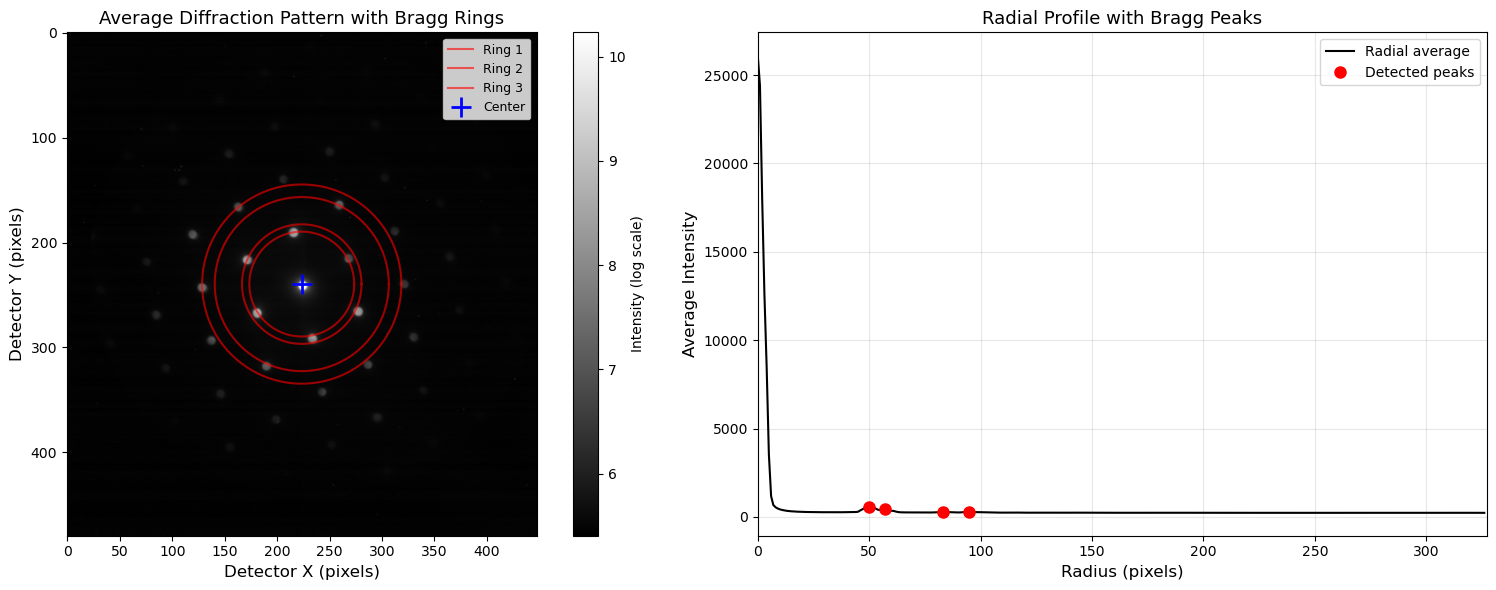

In [26]:
find_radial_intensity_profile(sige_calib)

In [27]:
sige_shifted = sige
sige_shifted.data = sige_calib

## Task 3: Virtual Detector Reconstruction

Generate a Virtual Bright Field (BF) image by integrating the central transmitted disk.

Generate an Annular Dark Field (ADF) image by integrating the scattered electrons in an outer ring.

Compare the Z-contrast in the ADF image to the diffraction contrast in the BF image.

## Function definition to run entire analysis pipeline

In [166]:
def run_pipeline(filename):
    try:
        # Implementing Hyperspy functionalities first to collect some calibration parameters
        data = hs.load(filename)
        s = data.transpose(navigation_axes=[2,3],signal_axes=[0,1]) # the navigation and signal axes in this dataset need to be swapped
        Rpixsize, Rpixunits = s.axes_manager.navigation_axes[0].scale, s.axes_manager.navigation_axes[0].units
        Qpixsize, Qpixunits = s.axes_manager.signal_axes[0].scale, s.axes_manager.signal_axes[0].units
        Rxsize, Rysize = s.axes_manager.navigation_axes[0].size, s.axes_manager.navigation_axes[1].size
        Qysize, Qxsize = s.axes_manager.signal_axes[0].size, s.axes_manager.signal_axes[1].size

        # Implementing py4DSTEM routines
        raw_datacube = p4.import_file(filename)
        datacube = raw_datacube.swap_RQ()

        datacube.calibration.set_R_pixel_size(Rpixsize)
        datacube.calibration.set_R_pixel_units(Rpixunits)
        datacube.set_dim(0, [0, Rpixsize], units=Rpixunits, name="Rx")
        datacube.set_dim(1, [0, Rpixsize], units=Rpixunits, name="Ry")
        if Qpixunits == '1/nm':
            datacube.calibration.set_Q_pixel_size(Qpixsize*0.1)
            datacube.calibration.set_Q_pixel_units('A^-1')
            datacube.set_dim(2, (np.arange(Qxsize) - (Qxsize/2)) * Qpixsize * 0.1, units='A^-1', name="Qx")
            datacube.set_dim(3, (np.arange(Qysize) - (Qysize/2)) * Qpixsize * 0.1, units='A^-1', name="Qy")
        else:
            datacube.calibration.set_Q_pixel_size(Qpixsize)
            datacube.calibration.set_Q_pixel_units(Qpixunits)
            datacube.set_dim(2, (np.arange(Qxsize) - (Qxsize/2)) * Qpixsize, units=Qpixunits, name="Qx")
            datacube.set_dim(3, (np.arange(Qysize) - (Qysize/2)) * Qpixsize, units=Qpixunits, name="Qy")

        datacube_com, ref_com, calibdata = com_calib(datacube)
        find_radial_intensity_profile(calibdata)

        datacube_calib = datacube
        datacube_calib.data = calibdata

        BF_img_fig, BF_img_ax = create_virtual_image(datacube_calib, 'circle', (Qxsize/2, Qysize/2), 20)
        ADF_img_fig, ADF_img_ax = create_virtual_image(datacube_calib, 'annular', (Qxsize/2, Qysize/2), (30,73))

        calib_params = {
            'R_pixel_size': Rpixsize,
            'R_pixel_units': Rpixunits,
            'Q_pixel_size': Qpixsize,
            'Q_pixel_units': Qpixunits,
            'Shape of R': (Rxsize, Rysize),
            'Shape of Q': (Qxsize, Qysize),
            'Origin_x': ref_com[0],
            'Origin_y': ref_com[1]
        }
        
        return calib_params, datacube_calib, BF_img_fig, ADF_img_fig
        
    except NameError:
        print('Metadata is missing from the 4D STEM dataset.')

Refined center from direct beam: (223.45, 239.55)


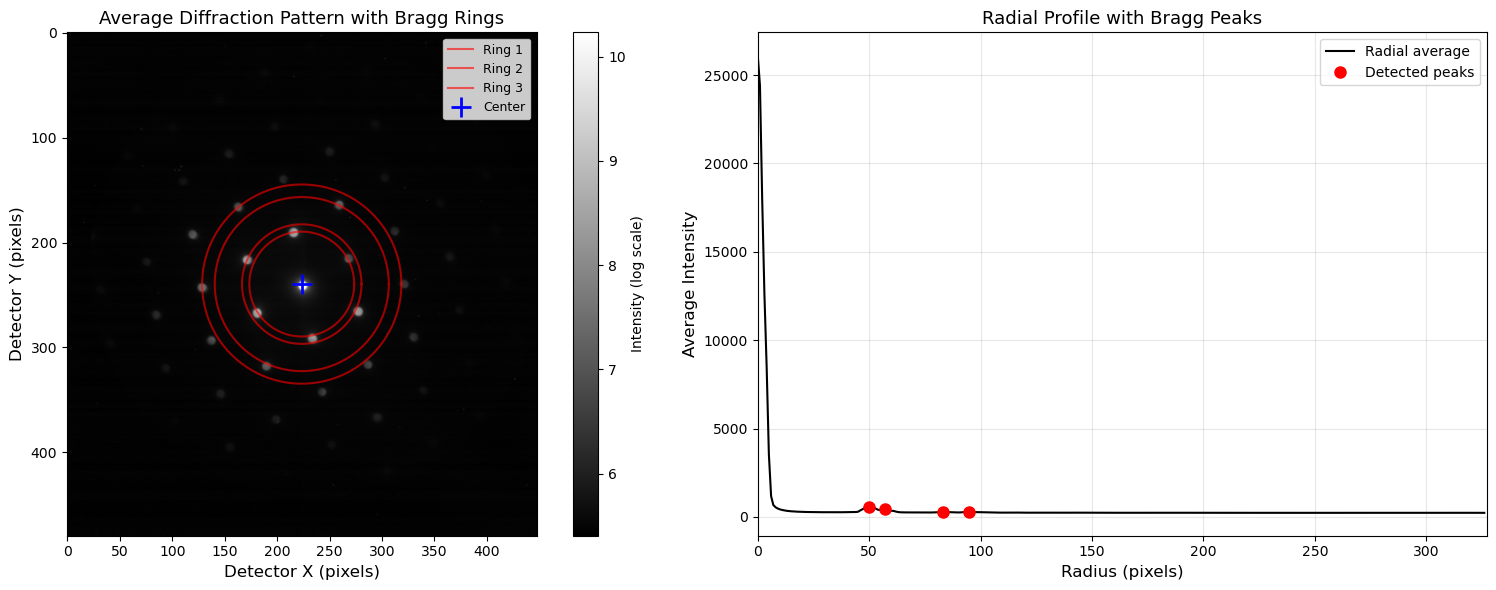

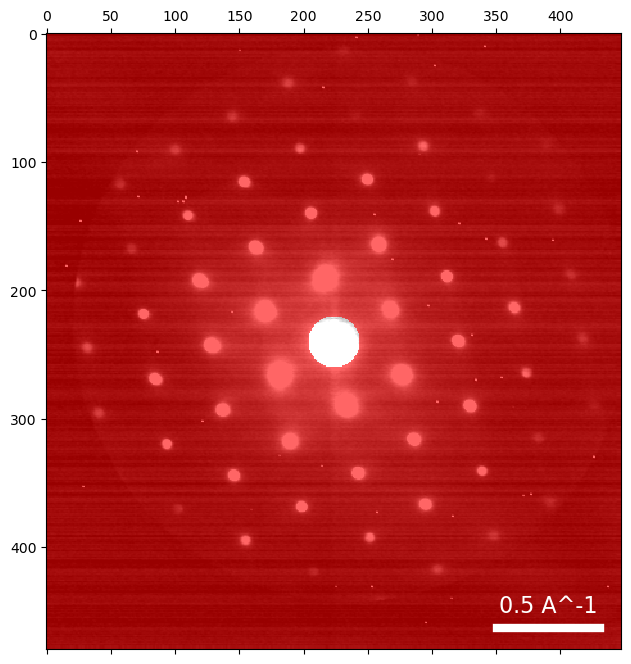

100%|████████████████████████████████████████████████████████████████████████████| 1309/1309 [00:00<00:00, 1351.94it/s]


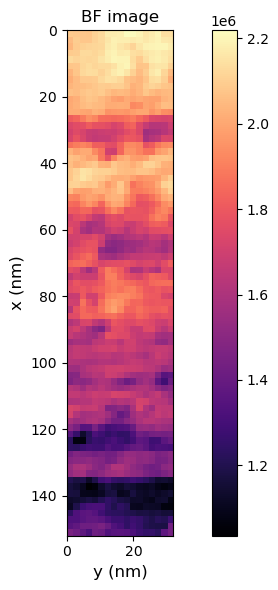

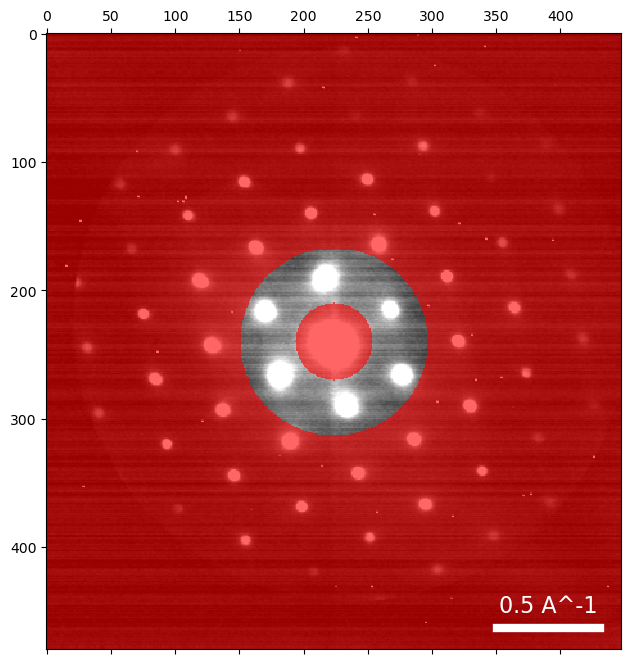

100%|████████████████████████████████████████████████████████████████████████████| 1309/1309 [00:00<00:00, 1498.95it/s]


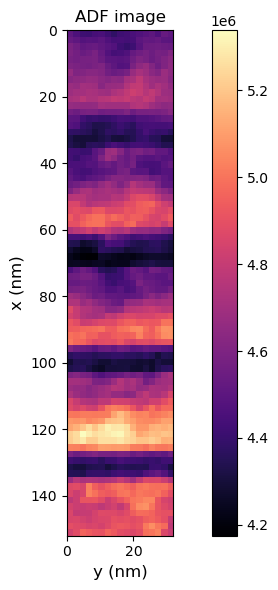

In [168]:
params, datacube_calib, BF_img, ADF_img = run_pipeline('/Users/wkddk/matsci465/Si-SiGe.dm4')

## Task 4: Basic 4D-STEM Visualization

Launch the interactive 4D-STEM browser using dataset.show() (if using a local GUI) or py4D.show_image().

Export a publication-quality figure of a virtual ADF image with a scale bar and a perceptually uniform colormap (e.g., magma).

In [2]:
# Your code here




from matplotlib.patches import Rectangle
if scale_bar_pixels < adf_image.shape[1] - 5:
    # Position scale bar in bottom-left corner
    bar_x, bar_y = 2, adf_image.shape[0] - 4
    scale_bar = Rectangle((bar_x, bar_y), scale_bar_pixels, 1, fill=True, color='white', linewidth=1)
    ax.add_patch(scale_bar)
    ax.text(bar_x + scale_bar_pixels/2, bar_y - 1, f'{scale_bar_length} nm', ha='center', va='top', 
            color='white', fontsize=10, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Integrated Intensity (a.u.)', fontsize=12)

plt.tight_layout()
plt.savefig('virtual_adf_figure_sisige.png', dpi=300, bbox_inches='tight')
plt.show()

## Task 5: Finalize and Submit

Update your README.md with a brief explanation of how virtual detectors allow post-acquisition imaging.

Push the completed Week 02 notebook to your GitHub repository.

Submit the repository link on Canvas.

In [ ]:
# Your code here